<a href="https://colab.research.google.com/github/sandeepkhadk/Next_Word_Prediction_With_Federated_learning/blob/main/fl_reddit_data_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

folder_path = '/content/drive/MyDrive/Next_word_prediction'
os.makedirs(folder_path, exist_ok=True)


In [ ]:
BASE_DIR = '/content/drive/MyDrive/Next_word_prediction'


In [ ]:
os.listdir(BASE_DIR)


['kaggle_RC_2019-05.csv']

In [ ]:
import pandas as pd

csv_path = f'{BASE_DIR}/kaggle_RC_2019-05.csv'
df = pd.read_csv(csv_path)

df.head()


,subreddit,body,controversiality,score
0,gameofthrones,Your submission has been automatically removed...,0,1
1,aww,"Dont squeeze her with you massive hand, you me...",0,19
2,gaming,It's pretty well known and it was a paid produ...,0,3
3,news,You know we have laws against that currently c...,0,10
4,politics,"Yes, there is a difference between gentle supp...",0,1


In [ ]:
import re
TEXT_COL = 'body'

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)              # remove mentions
    text = re.sub(r"[^a-z\s]", "", text)          # keep letters only
    text = re.sub(r"\s+", " ", text).strip()
    return text

df[TEXT_COL] = df[TEXT_COL].apply(clean_text)


In [ ]:
df

,subreddit,body,controversiality,score
0,gameofthrones,your submission has been automatically removed...,0,1
1,aww,dont squeeze her with you massive hand you mea...,0,19
2,gaming,its pretty well known and it was a paid produc...,0,3
3,news,you know we have laws against that currently c...,0,10
4,politics,yes there is a difference between gentle suppr...,0,1
...,...,...,...,...
999995,Pikabu,,0,1
999996,Pikabu,,0,2
999997,Pikabu,,0,1
999998,Pikabu,,0,-5


In [ ]:
df = df[df[TEXT_COL].str.split().str.len() >= 3]


In [ ]:
df

,subreddit,body,controversiality,score
0,gameofthrones,your submission has been automatically removed...,0,1
1,aww,dont squeeze her with you massive hand you mea...,0,19
2,gaming,its pretty well known and it was a paid produc...,0,3
3,news,you know we have laws against that currently c...,0,10
4,politics,yes there is a difference between gentle suppr...,0,1
...,...,...,...,...
999962,Pikabu,nokia connecting peoples,0,1
999973,Pikabu,sorry your account should be at least day old ...,0,1
999977,Pikabu,xkcd a webcomic of romance sarcasm math and la...,0,10
999979,Pikabu,the weather is fine,0,3


In [ ]:
keep_subreddits = ['gaming', 'politics','news','movies','funny','AskReddit','nba','unpopularopinion','memes','Animemes']

# Filter DataFrame
df = df[df['subreddit'].isin(keep_subreddits)]
df.head()
df

,subreddit,body,controversiality,score
2,gaming,its pretty well known and it was a paid produc...,0,3
3,news,you know we have laws against that currently c...,0,10
4,politics,yes there is a difference between gentle suppr...,0,1
7,nba,report water is wet,0,9
10,AskReddit,like a giant turd that feels like its coming o...,0,2
...,...,...,...,...
982286,Animemes,i have in one day and ive given up on studying...,0,1
982287,Animemes,i know what you mean and i totally agree,0,2
982288,Animemes,you could squeeze one out during work if youre...,0,3
982296,Animemes,you dont speak of the deity behind the th wall...,0,2


In [ ]:
df['comment_length'] = df['body'].apply(lambda x: len(x.split()))


/tmp/ipython-input-1599308368.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['comment_length'] = df['body'].apply(lambda x: len(x.split()))


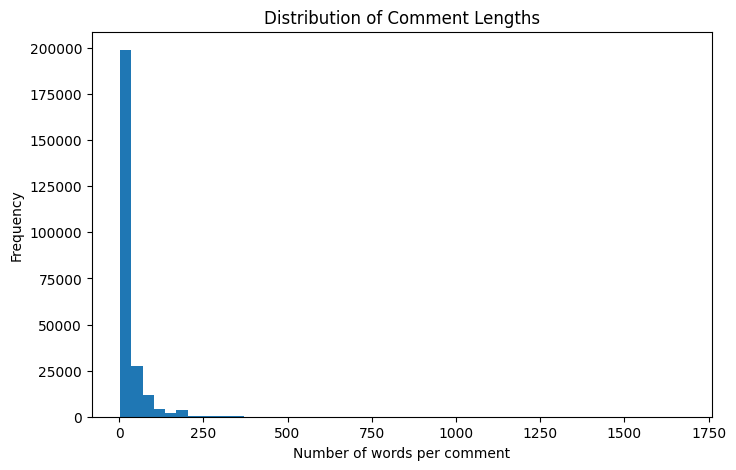

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['comment_length'], bins=50)
plt.xlabel("Number of words per comment")
plt.ylabel("Frequency")
plt.title("Distribution of Comment Lengths")
plt.show()


In [ ]:
MAX_VOCAB = 20000
MAX_SEQ_LEN = 50   # from your histogram


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=MAX_VOCAB,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(df['body'])

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

X, y = [], []

for text in df['body']:
    token_list = tokenizer.texts_to_sequences([text])[0]
    token_list = token_list[:MAX_SEQ_LEN]

    for i in range(1, len(token_list)):
        X.append(token_list[:i])
        y.append(token_list[i])

X = pad_sequences(X, maxlen=MAX_SEQ_LEN, padding='pre')
y = np.array(y)


In [ ]:
df

,subreddit,body,controversiality,score,comment_length
2,gaming,its pretty well known and it was a paid produc...,0,3,65
3,news,you know we have laws against that currently c...,0,10,21
4,politics,yes there is a difference between gentle suppr...,0,1,15
7,nba,report water is wet,0,9,4
10,AskReddit,like a giant turd that feels like its coming o...,0,2,11
...,...,...,...,...,...
982286,Animemes,i have in one day and ive given up on studying...,0,1,30
982287,Animemes,i know what you mean and i totally agree,0,2,9
982288,Animemes,you could squeeze one out during work if youre...,0,3,11
982296,Animemes,you dont speak of the deity behind the th wall...,0,2,12


In [ ]:
X.shape

(4848430, 50)

In [ ]:
y.shape

(4848430,)

In [ ]:
X

array([[  0,   0,   0, ...,   0,   0,  26],
       [  0,   0,   0, ...,   0,  26, 175],
       [  0,   0,   0, ...,  26, 175,  93],
       ...,
       [  0,   0,   0, ..., 174,   2, 544],
       [  0,   0,   0, ...,   2, 544,  10],
       [  0,   0,   0, ..., 544,  10,   1]], dtype=int32)

In [ ]:
y

array([  175,    93,   936, ...,    10,     1, 15026])

In [ ]:
from tensorflow.keras.layers import Embedding

MAX_VOCAB = 20000
EMBED_DIM = 100
MAX_SEQ_LEN = 50

embedding_layer = Embedding(
    input_dim=MAX_VOCAB,
    output_dim=EMBED_DIM,
    input_length=MAX_SEQ_LEN
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
sample_X = X[:555]   # small batch only
embedded_X = embedding_layer(sample_X)

print(embedded_X.shape)


(555, 50, 100)


In [ ]:
embedded_X

<tf.Tensor: shape=(555, 50, 100), dtype=float32, numpy=
array([[[-0.0361959 ,  0.00159421,  0.02732135, ...,  0.02547668,
         -0.01622026,  0.03235866],
        [-0.0361959 ,  0.00159421,  0.02732135, ...,  0.02547668,
         -0.01622026,  0.03235866],
        [-0.0361959 ,  0.00159421,  0.02732135, ...,  0.02547668,
         -0.01622026,  0.03235866],
        ...,
        [-0.0361959 ,  0.00159421,  0.02732135, ...,  0.02547668,
         -0.01622026,  0.03235866],
        [-0.0361959 ,  0.00159421,  0.02732135, ...,  0.02547668,
         -0.01622026,  0.03235866],
        [-0.03915896, -0.04322308,  0.01566145, ..., -0.00166531,
          0.03078132,  0.01099483]],

       [[-0.0361959 ,  0.00159421,  0.02732135, ...,  0.02547668,
         -0.01622026,  0.03235866],
        [-0.0361959 ,  0.00159421,  0.02732135, ...,  0.02547668,
         -0.01622026,  0.03235866],
        [-0.0361959 ,  0.00159421,  0.02732135, ...,  0.02547668,
         -0.01622026,  0.03235866],
        ...

In [ ]:
sample_y = y[:555]   # small batch only
embedded_y = embedding_layer(sample_y)

print(embedded_y.shape)


(555, 100)


In [ ]:
embedded_y

<tf.Tensor: shape=(555, 100), dtype=float32, numpy=
array([[ 0.00606121, -0.0233943 , -0.00119538, ..., -0.0298566 ,
         0.02627298, -0.00208898],
       [-0.02627493,  0.0239447 , -0.032099  , ...,  0.03609954,
        -0.00481854,  0.0268703 ],
       [ 0.04128976, -0.00877779,  0.02930148, ..., -0.02051815,
         0.03767878,  0.01479309],
       ...,
       [ 0.03073094, -0.02927184, -0.0398199 , ..., -0.03713287,
        -0.04798701,  0.02601771],
       [ 0.00496604, -0.00467117,  0.01649423, ...,  0.03407928,
        -0.03566443, -0.01747347],
       [ 0.00919695,  0.01143127,  0.02206662, ..., -0.04747795,
         0.00119271, -0.0268101 ]], dtype=float32)>